# Procrustes Alignment Demonstration

This notebook demonstrates the three steps of Procrustes alignment using synthetic pose data:
1. **Translation** — Center poses to the same origin
2. **Scale** — Normalize poses to the same size
3. **Rotation** — Align orientation (2D roll)

Using synthetic data allows us to show exactly what each step corrects.

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

np.random.seed(42)

## Create a Template Skeleton

We'll create a simple 2D skeleton with clear anatomical structure.

In [86]:
# OpenPose COCO 18-keypoint format (centered at origin)
# Keypoint indices follow classic OpenPose naming
template = np.array([
    # 0: Nose
    [0.0, 0.45],
    # 1: Neck
    [0.0, 0.30],
    # 2: Right Shoulder
    [0.15, 0.28],
    # 3: Right Elbow
    [0.25, 0.12],
    # 4: Right Wrist
    [0.30, -0.02],
    # 5: Left Shoulder
    [-0.15, 0.28],
    # 6: Left Elbow
    [-0.25, 0.12],
    # 7: Left Wrist
    [-0.30, -0.02],
    # 8: Right Hip
    [0.08, 0.0],
    # 9: Right Knee
    [0.10, -0.25],
    # 10: Right Ankle
    [0.10, -0.50],
    # 11: Left Hip
    [-0.08, 0.0],
    # 12: Left Knee
    [-0.10, -0.25],
    # 13: Left Ankle
    [-0.10, -0.50],
    # 14: Right Eye
    [0.04, 0.48],
    # 15: Left Eye
    [-0.04, 0.48],
    # 16: Right Ear
    [0.08, 0.46],
    # 17: Left Ear
    [-0.08, 0.46],
])

# OpenPose COCO skeleton connections
skeleton_pairs = [
    # Face
    (0, 14), (0, 15),    # nose to eyes
    (14, 16), (15, 17),  # eyes to ears
    # Neck connections
    (0, 1),              # nose to neck
    (1, 2), (1, 5),      # neck to shoulders
    # Right arm
    (2, 3), (3, 4),      # shoulder -> elbow -> wrist
    # Left arm
    (5, 6), (6, 7),      # shoulder -> elbow -> wrist
    # Torso
    (1, 8), (1, 11),     # neck to hips
    # Right leg
    (8, 9), (9, 10),     # hip -> knee -> ankle
    # Left leg
    (11, 12), (12, 13),  # hip -> knee -> ankle
]

print(f"Template has {len(template)} keypoints (OpenPose COCO format)")
print(f"Template centroid: {template.mean(axis=0)}")

Template has 18 keypoints (OpenPose COCO format)
Template centroid: [-6.16790569e-18  1.05000000e-01]


## Generate Synthetic "Participants"

We'll create two synthetic poses with known transformations:
- **Participant 1**: Translated left, scaled smaller, rotated clockwise
- **Participant 2**: Translated right, scaled larger, rotated counter-clockwise

In [87]:
def apply_transform(pose, translation=(0, 0), scale=1.0, rotation_deg=0, noise_std=0.0):
    """Apply translation, scale, rotation, and optional noise to a pose."""
    # Center the pose
    centroid = pose.mean(axis=0)
    centered = pose - centroid
    
    # Scale
    scaled = centered * scale
    
    # Rotate (2D rotation matrix)
    theta = np.radians(rotation_deg)
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    rotated = scaled @ R.T
    
    # Translate
    final = rotated + centroid + np.array(translation)
    
    # Add noise to simulate natural variation and tracking jitter
    if noise_std > 0:
        noise = np.random.randn(*final.shape) * noise_std
        final = final + noise
    
    return final

# Create two synthetic participants with different transforms + realistic noise
participant1 = apply_transform(
    template,
    translation=(-0.3, 0.1),   # shifted left and up
    scale=0.8,                  # smaller
    rotation_deg=8,             # slight tilt clockwise
    noise_std=0.015             # small jitter
)

participant2 = apply_transform(
    template,
    translation=(0.25, -0.05),  # shifted right and down
    scale=1.2,                   # larger
    rotation_deg=-12,            # slight tilt counter-clockwise
    noise_std=0.018              # slightly more jitter
)

print("Participant 1: translated=(-0.3, 0.1), scale=0.8, rotation=8° + noise")
print("Participant 2: translated=(0.25, -0.05), scale=1.2, rotation=-12° + noise")

Participant 1: translated=(-0.3, 0.1), scale=0.8, rotation=8° + noise
Participant 2: translated=(0.25, -0.05), scale=1.2, rotation=-12° + noise


## Visualization Helper Functions

In [88]:
def draw_skeleton(ax, pose, color, label=None, alpha=0.7, lw=1.5, s=20, zorder=2):
    """Draw a skeleton on an axis."""
    ax.scatter(pose[:, 0], pose[:, 1], c=color, s=s, alpha=alpha, zorder=zorder+1)
    for i1, i2 in skeleton_pairs:
        ax.plot([pose[i1, 0], pose[i2, 0]], 
                [pose[i1, 1], pose[i2, 1]], 
                c=color, alpha=alpha, lw=lw, zorder=zorder)
    if label:
        ax.scatter([], [], c=color, label=label, s=40)

def draw_template(ax, template_pose):
    """Draw the template skeleton in black."""
    draw_skeleton(ax, template_pose, 'black', label='Template', alpha=0.9, lw=2, s=30, zorder=10)

## Procrustes Alignment Steps

Now let's show each step of the alignment process.

In [89]:
def procrustes_steps(pose, template):
    """
    Apply Procrustes alignment step by step.
    Returns intermediate results for visualization.
    """
    tmpl_centroid = template.mean(axis=0)
    tmpl_centered = template - tmpl_centroid
    tmpl_norm = np.linalg.norm(tmpl_centered)
    
    # Step 0: Raw
    raw = pose.copy()
    
    # Step 1: Translation — shift centroid to template centroid
    pose_centroid = pose.mean(axis=0)
    translated = pose + (tmpl_centroid - pose_centroid)
    
    # Step 2: Scale — match size to template
    trans_centered = translated - tmpl_centroid
    pose_norm = np.linalg.norm(trans_centered)
    scale_factor = tmpl_norm / pose_norm
    scaled_centered = trans_centered * scale_factor
    scaled = scaled_centered + tmpl_centroid
    
    # Step 3: Rotation — align orientation
    R, _ = orthogonal_procrustes(scaled_centered, tmpl_centered)
    rotated_centered = scaled_centered @ R
    rotated = rotated_centered + tmpl_centroid
    
    # Extract rotation angle for display
    angle_deg = np.degrees(np.arctan2(R[1, 0], R[0, 0]))
    
    return {
        'raw': raw,
        'translated': translated,
        'scaled': scaled,
        'rotated': rotated,
        'scale_factor': scale_factor,
        'rotation_deg': angle_deg
    }

In [90]:
# Apply Procrustes steps to both participants
p1_steps = procrustes_steps(participant1, template)
p2_steps = procrustes_steps(participant2, template)

print(f"Participant 1: scale={p1_steps['scale_factor']:.3f}, rotation={p1_steps['rotation_deg']:.1f}°")
print(f"Participant 2: scale={p2_steps['scale_factor']:.3f}, rotation={p2_steps['rotation_deg']:.1f}°")

Participant 1: scale=1.234, rotation=8.0°
Participant 2: scale=0.825, rotation=-12.5°


## 4-Panel Visualization

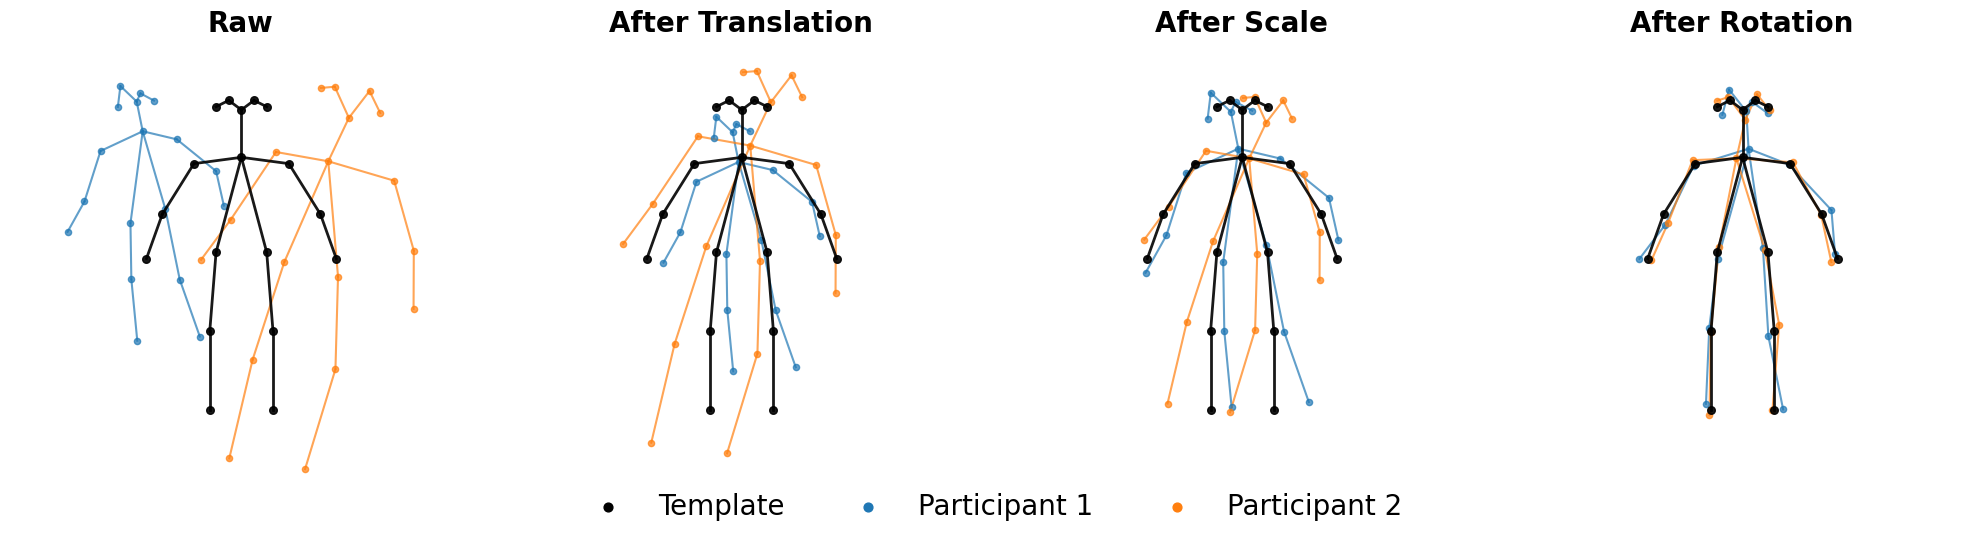

In [91]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

stages = ['raw', 'translated', 'scaled', 'rotated']
titles = ['Raw', 'After Translation', 'After Scale', 'After Rotation']
colors = ['tab:blue', 'tab:orange']

# Compute shared axis limits from all data
all_points = np.vstack([
    template,
    p1_steps['raw'], p1_steps['translated'], p1_steps['scaled'], p1_steps['rotated'],
    p2_steps['raw'], p2_steps['translated'], p2_steps['scaled'], p2_steps['rotated']
])
x_min, y_min = all_points.min(axis=0) - 0.1
x_max, y_max = all_points.max(axis=0) + 0.1
max_range = max(x_max - x_min, y_max - y_min)
x_center, y_center = (x_min + x_max) / 2, (y_min + y_max) / 2

for ax, stage, title in zip(axes, stages, titles):
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(x_center - max_range/2, x_center + max_range/2)
    ax.set_ylim(y_center - max_range/2, y_center + max_range/2)
    
    # Draw template
    draw_template(ax, template)
    
    # Draw participants at this stage
    draw_skeleton(ax, p1_steps[stage], colors[0], label='Participant 1' if stage == 'raw' else None)
    draw_skeleton(ax, p2_steps[stage], colors[1], label='Participant 2' if stage == 'raw' else None)

# Add legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=20, 
           bbox_to_anchor=(0.5, -0.08), frameon=False)

plt.show()

## Summary

The figure above shows how Procrustes alignment progressively aligns poses:

1. **Raw**: Participants have different positions, sizes, and orientations
2. **Translation**: All poses are centered on the template centroid
3. **Scale**: All poses are normalized to the same size as the template
4. **Rotation**: All poses are rotated to match the template orientation

After all steps, the colored skeletons should closely overlap the black template.

In [92]:
# Save figure for use in papers/presentations
fig.savefig('procrustes_alignment_demo.png', dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("Saved to procrustes_alignment_demo.png")

Saved to procrustes_alignment_demo.png
